In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('customer_segmentation.csv')

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [6]:
df.shape

(2240, 29)

In [7]:
df.isnull().sum().sum()

np.int64(24)

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [11]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [12]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [13]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   str           
 3   Marital_Status       2216 non-null   str           
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[us]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   int64       

In [15]:
df['Age'] = 2026 - df['Year_Birth']

In [16]:
df['Age']

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,45


In [18]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [19]:
df['Total_Children']

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2216, dtype: int64

In [20]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='str')

In [21]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

In [22]:
df['Total_Spent'] = df[spend_cols].sum(axis=1)

In [23]:
df['Total_Spent']

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spent, Length: 2216, dtype: int64

In [24]:
df['Customer_Since'] = (pd.Timestamp("today") - df['Dt_Customer']).dt.days

In [25]:
df['Customer_Since']

0       5087
1       4537
2       4736
3       4563
4       4585
        ... 
2235    4805
2236    4443
2237    4579
2238    4580
2239    5046
Name: Customer_Since, Length: 2216, dtype: int64

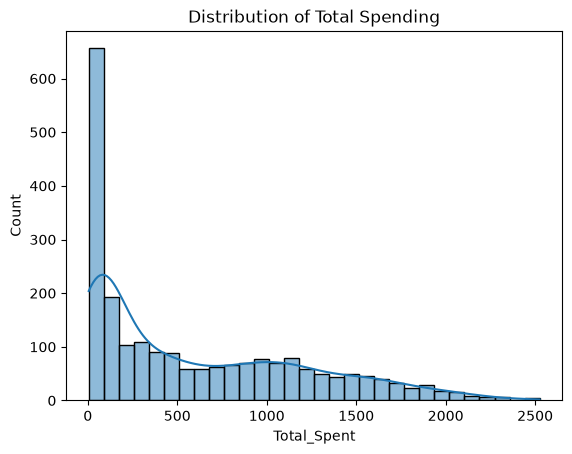

In [26]:
# Exploratory Data Analysis (EDA)

sns.histplot(data=df, x='Total_Spent', bins=30, kde=True)
plt.title('Distribution of Total Spending')
plt.show()

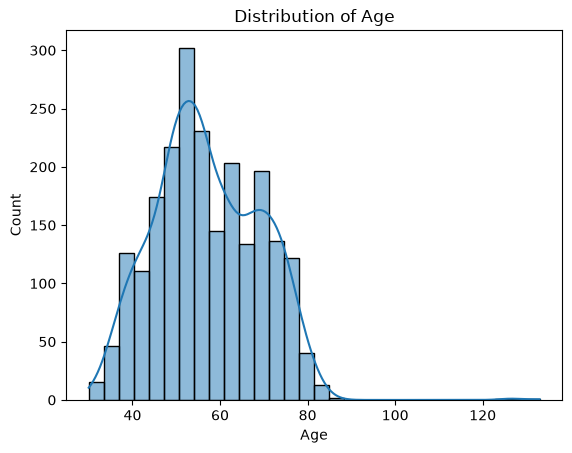

In [27]:
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Distribution of Age')
plt.show()

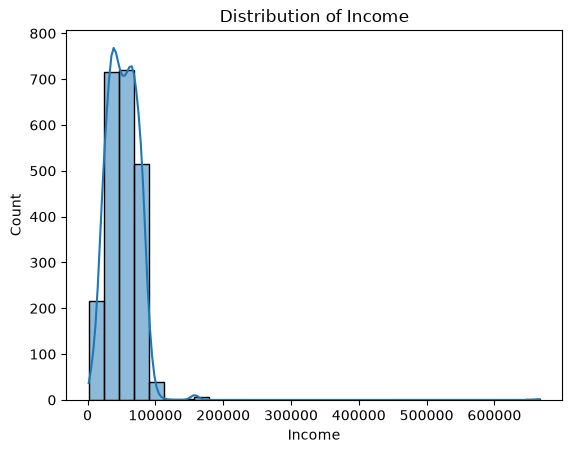

In [28]:
sns.histplot(data=df, x='Income', bins=30, kde=True)
plt.title('Distribution of Income')
plt.show()

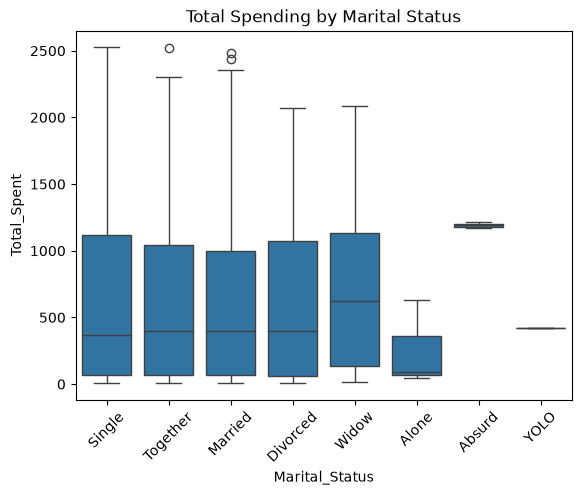

In [29]:
sns.boxplot(x='Marital_Status', y='Total_Spent', data=df)
plt.xticks(rotation=45)
plt.title('Total Spending by Marital Status')
plt.show()

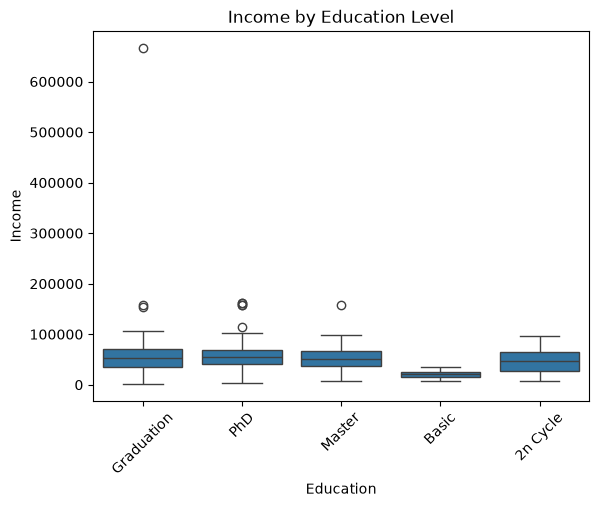

In [30]:
sns.boxplot(x='Education', y='Income', data=df)
plt.xticks(rotation=45)
plt.title('Income by Education Level')
plt.show()

In [31]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spent', 'Customer_Since'],
      dtype='str')

In [32]:
corr = df[['Income', 'Age', 'Total_Spent', 'Recency', 'NumDealsPurchases', 'NumStorePurchases']].corr()

In [33]:
corr

,Income,Age,Total_Spent,Recency,NumDealsPurchases,NumStorePurchases
Income,1.000000,0.161791,0.667576,-0.003970,-0.083101,0.529362
Age,0.161791,1.000000,0.113487,0.016295,0.058668,0.127891
Total_Spent,0.667576,0.113487,1.000000,0.020066,-0.065854,0.675181
Recency,-0.003970,0.016295,0.020066,1.000000,0.002115,-0.000434
NumDealsPurchases,-0.083101,0.058668,-0.065854,0.002115,1.000000,0.066107
NumStorePurchases,0.529362,0.127891,0.675181,-0.000434,0.066107,1.000000


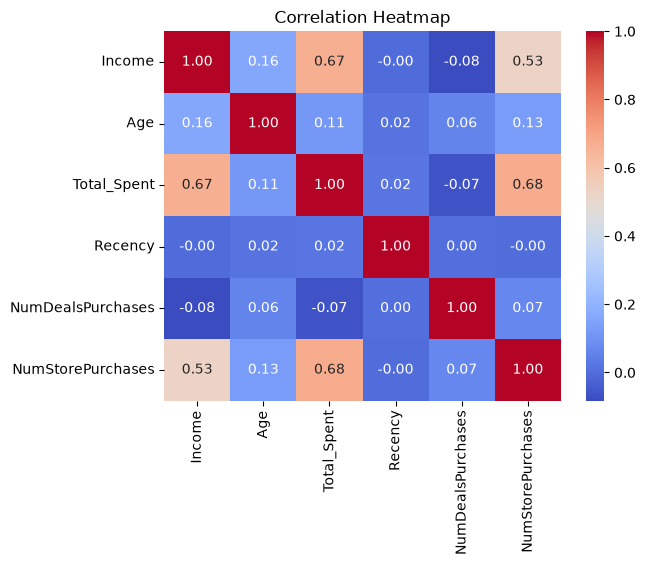

In [34]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [35]:
pivot_income = df.pivot_table(values='Income', index='Education', columns='Marital_Status', aggfunc='mean')

In [36]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by Education and Marital Status')

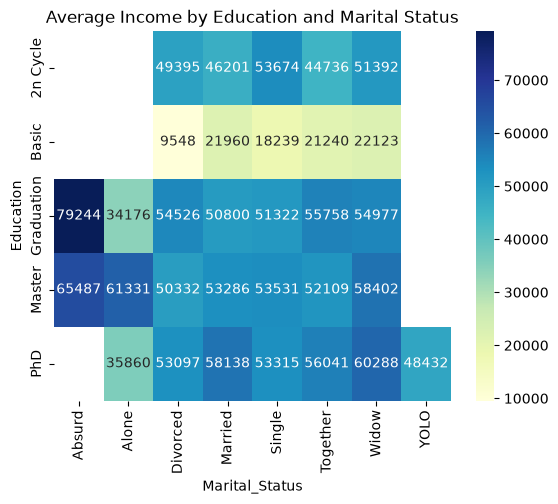

In [37]:
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Average Income by Education and Marital Status')

In [38]:
group1 = df.groupby('Education')['Total_Spent'].mean().sort_values(ascending=False)
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spent, dtype: float64

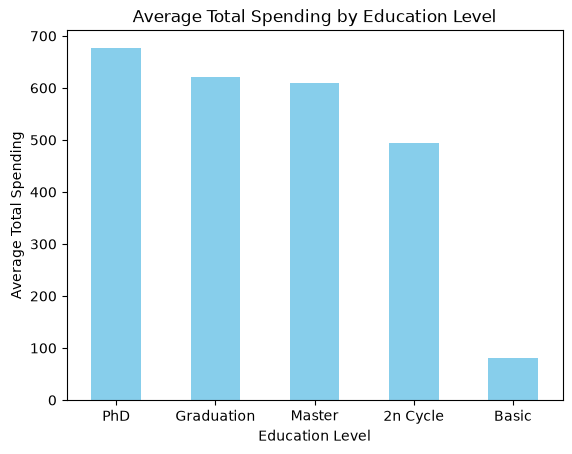

In [39]:
group1.plot(kind='bar', color='skyblue')
plt.title('Average Total Spending by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Total Spending')
plt.xticks(rotation=0)
plt.show()

In [40]:
df['Accepted_Any'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1)
df['Accepted_Any']

0       1
1       0
2       0
3       0
4       0
       ..
2235    0
2236    1
2237    1
2238    0
2239    1
Name: Accepted_Any, Length: 2216, dtype: int64

In [41]:
df['Accepted_Any'].value_counts()

Accepted_Any
0    1611
1     369
2     139
3      51
4      36
5      10
Name: count, dtype: int64

In [42]:
df['Accepted_Any'] = df['Accepted_Any'].apply(lambda x: 1 if x > 0 else 0)
df['Accepted_Any'].value_counts()

Accepted_Any
0    1611
1     605
Name: count, dtype: int64

In [43]:
group2 = df.groupby('Marital_Status')['Accepted_Any'].mean().sort_values(ascending=False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: Accepted_Any, dtype: float64

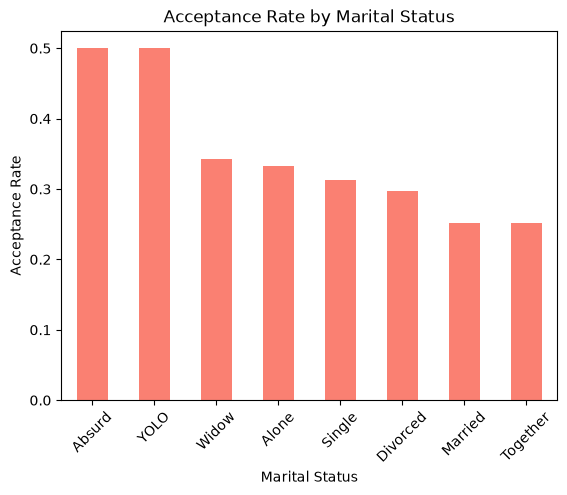

In [44]:
group2.plot(kind='bar', color='salmon')
plt.title('Acceptance Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=45)
plt.show()

In [45]:
# To find average income by age group.
bins, labels = [18, 25, 35, 45, 55, 65, 75, 100], ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']

In [46]:
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df['Age_Group']

0       65-74
1       65-74
2       55-64
3       35-44
4       45-54
        ...  
2235    55-64
2236      75+
2237    45-54
2238    65-74
2239    65-74
Name: Age_Group, Length: 2216, dtype: category
Categories (7, str): ['18-24' < '25-34' < '35-44' < '45-54' < '55-64' < '65-74' < '75+']

In [47]:
group3 = df.groupby('Age_Group')['Income'].mean().sort_values(ascending=True)
group3

Age_Group
35-44    45656.522293
45-54    49570.409861
55-64    52535.158895
25-34    56265.892857
65-74    56876.545064
75+      59855.587571
Name: Income, dtype: float64

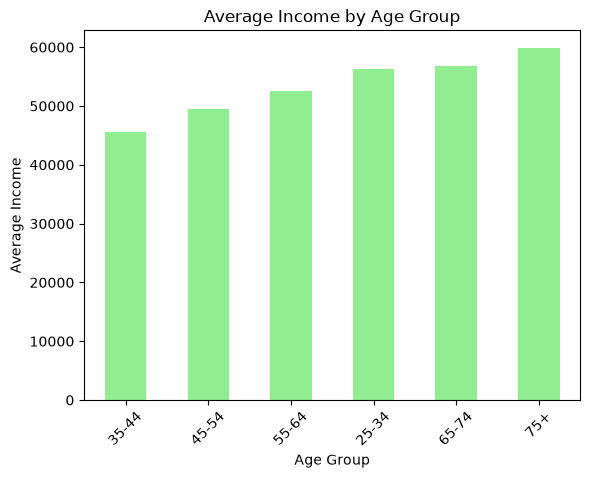

In [48]:
group3.plot(kind='bar', color='lightgreen')
plt.title('Average Income by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Income')
plt.xticks(rotation=45)
plt.show()

In [49]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spent,Customer_Since,Accepted_Any,Age_Group
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,69,0,1617,5087,1,65-74
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,72,2,27,4537,0,65-74
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,61,0,776,4736,0,55-64
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,42,1,53,4563,0,35-44
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,45,1,422,4585,0,45-54


In [50]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spent', 'Customer_Since',
       'Accepted_Any', 'Age_Group'],
      dtype='str')

In [51]:
features=['Age', 'Income', 'Total_Spent', 'Recency', 'NumStorePurchases', 'NumWebVisitsMonth', 'NumWebPurchases']

In [52]:
X = df[features].copy()
X

,Age,Income,Total_Spent,Recency,NumStorePurchases,NumWebVisitsMonth,NumWebPurchases
0,69,58138.0,1617,58,4,7,8
1,72,46344.0,27,38,2,5,1
2,61,71613.0,776,26,10,4,8
3,42,26646.0,53,26,4,6,2
4,45,58293.0,422,94,6,5,5
...,...,...,...,...,...,...,...
2235,59,61223.0,1341,46,4,5,9
2236,80,64014.0,444,56,5,7,8
2237,45,56981.0,1241,91,13,6,2
2238,70,69245.0,843,8,10,3,6


In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [54]:
X_scaled = scaler.fit_transform(X)

In [55]:
# We need k for like a grouping number which is the number of cluster and there we have to determine the optimal number cluster called elbow method.
from sklearn.cluster import KMeans

In [56]:
wcss=[]
for i in range(2,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [57]:
wcss

[10218.62014374878,
 9007.786818672812,
 8239.330494762798,
 7882.438885892298,
 7207.644848352461,
 7042.172672693945,
 6606.632613981039,
 5877.112184434608]

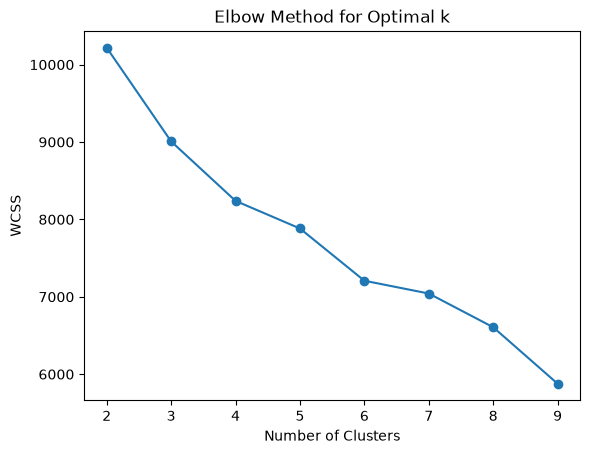

In [58]:
plt.plot(range(2,10), wcss, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [60]:
# Here we need to select one elbow bands both four or six will work. I am going to take 6 since its think better. So we are going to initilize it. 

kmeans = KMeans(n_clusters=6)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [61]:
df['Cluster']

0       5
1       0
2       5
3       1
4       4
       ..
2235    5
2236    5
2237    3
2238    2
2239    0
Name: Cluster, Length: 2216, dtype: int32

In [64]:
# Original Dataframe
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spent,Customer_Since,Accepted_Any,Age_Group,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,69,0,1617,5087,1,65-74,5
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,72,2,27,4537,0,65-74,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,61,0,776,4736,0,55-64,5
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,42,1,53,4563,0,35-44,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,45,1,422,4585,0,45-54,4


In [67]:
#Lets analyze this cluster. Mmportant point of project. We are going to create characteristics of the clusters like. Let's say cluster 1 contains the older people with more income and stuff like... We can call cluster summary. 

cluster_summary = df.groupby("Cluster")[features].mean()

In [68]:
cluster_summary

,Age,Income,Total_Spent,Recency,NumStorePurchases,NumWebVisitsMonth,NumWebPurchases
Cluster,,,,,,,
0,69.751773,44049.475177,182.418440,38.290780,4.056738,5.553191,2.673759
1,48.800885,31811.132743,108.876106,26.865044,3.148230,6.820796,2.143805
2,70.458462,73544.796923,1200.753846,52.292308,8.510769,2.760000,4.652308
3,47.276596,78226.303951,1299.203647,49.665653,8.583587,2.650456,4.562310
4,52.875895,35149.582339,133.410501,79.369928,3.441527,6.582339,2.436754
5,59.594132,60178.819071,907.195599,46.650367,7.960880,6.383863,8.058680


In [69]:
df['Cluster'].value_counts()

Cluster
1    452
4    419
5    409
3    329
2    325
0    282
Name: count, dtype: int64

In [71]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]


In [72]:
pca_data

array([[ 1.1075188 , -0.21175951],
       [-1.33673385,  0.269839  ],
       [ 1.88227676, -1.01416098],
       ...,
       [ 1.1535966 ,  1.15056999],
       [ 1.88768024, -1.16073698],
       [-0.84182091, -0.15963623]], shape=(2216, 2))

In [73]:
df['PCA2']

0      -0.211760
1       0.269839
2      -1.014161
3      -0.704928
4       1.235265
          ...   
2235   -0.535766
2236   -0.141328
2237    1.150570
2238   -1.160737
2239   -0.159636
Name: PCA2, Length: 2216, dtype: float64

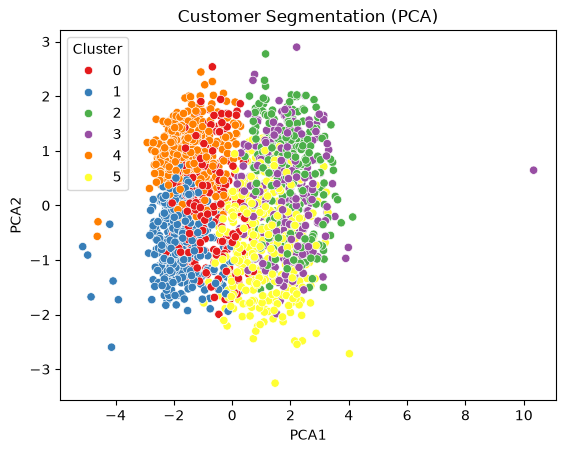

In [74]:
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("Customer Segmentation (PCA)")
plt.show()
# See segmentation so we have 6 cluster in our data. 

In [75]:
#Now We have made our model in our table but we want to turn it into a schema table, we firstly need to train model and scale model. 

import joblib
joblib.dump(kmeans,"kmeans_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [76]:
# We have K-means model.picle with scaler.pkl so now we are done with notebook. 
# We have did a lot of analysis feature engineering, data cleaning, and we modeled our data. We have six clusters right now.